In [1]:
import csv
import json
import tiktoken


# Data preperation

In [2]:
# First convert csv file to json

csv_file = "/content/Formatted-MSA-prompts-stories-for-fine-tuning_utf8.csv"
json_file = "/content/Formatted-MSA-prompts-stories-for-fine-tuning_utf8.json"

data = []

with open(csv_file, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        # Each row becomes a JSON object
        data.append({
            "instruction": row["Prompt"],
            "output": row["Story"]
        })

# Save as JSON file
with open(json_file, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

In [2]:
# Open the file and check it
json_file = "/content/Formatted-MSA-prompts-stories-for-fine-tuning_utf8.json"

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# print first 5 lines
for i, item in enumerate(data[:5]):
    print(f"Item {i+1}:")
    print(item)
    print("-" * 40)
print("Number of items in JSON:", len(data))

Item 1:
{'instruction': 'أكتب قصة قصيرة تكون مفهومة للأطفال في عمر 5-8. أحداث القصة يجب أن تدور في القصر. نهاية القصة يجب أن تكون سعيدة. يجب أن يكون هناك حوار. عدد الشخصيات في القصة يجب أن يكون 2. بلد الأحداث هي  قطر. الأحداث تدور في فصل الصيف. يجب أن تحتوي القصة على شعور بالانزعاج.  أكتب القصة مباشرة.', 'output': 'في قصرٍ عظيم في قطر، كان يعيش الأمير جمال وقطه الأليف ميسو. كان الصيف في كامل ألقه، لكن الحرارة كانت شديدة لدرجة أن جمال وميسو شعرا بالانزعاج الشديد. \n\nذات يوم، قال جمال متأففًا: "يا ميسو، كيف يمكننا الاستمتاع بهذا الصيف والحرارة شديدة هكذا؟"\n\nميسو، بنظرة حزينة رد مواءً كأنه يوافق صديقه الأمير على شعوره بالانزعاج.\n\nفكر الأمير جمال قليلاً وقال: "لدي فكرة! ما رأيك أن نحول القصر إلى مكان للمتعة واللعب؟ يمكننا إقامة مسبح مؤقت في حديقة القصر."\n\nلمعت عينا ميسو بفرح، وبدا وكأنه يبتسم موافقًا على الفكرة.\n\nبسرعة، عمل الأمير جمال وقطه ميسو على تجهيز المسبح. كان جمال يضحك وميسو يطارد الفقاعات المائية ويحاول القفز للإمساك بها. تحول القصر من مكان يسوده الانزعاج بسبب الحر إلى مس

In [3]:
def format_input(entry):
    instruction_text = (
        f".في الأسفل تعليمة تصف المهمة المطلوبة"
        f".أكتب رد مناسب يجيب على المطلوب"
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    # Check if 'input' key exists and has a truthy value, otherwise use an empty string
    # This data has has no input entry
    input_content = entry.get('input', '')
    input_text = f"\n\n### Input:\n{input_content}" if input_content else ""

    return instruction_text + input_text


In [4]:
model_input = format_input(data[50])
print(model_input)

.في الأسفل تعليمة تصف المهمة المطلوبة.أكتب رد مناسب يجيب على المطلوب

### Instruction:
أكتب قصة قصيرة تكون مفهومة للأطفال في عمر 5-8. نهاية القصة يجب أن تكون سعيدة. عدد الشخصيات في القصة يجب أن يكون 3. الدرس المستفاد من القصة هو اتق شر من أحسنت اليه. بلد الأحداث هي  مصر. أضف تحولا غير متوقع في الأحداث: التحول من حلم إلى واقع. أكتب القصة مباشرة.


In [5]:
# prepare the train, validation,test splits

train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [7]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 846
Validation set length: 51
Test set length: 99


# Padding

In [6]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [7]:
# Initialize tokenizer
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [8]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="gpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [11]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

# Data loader for all splits

In [13]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 2

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [14]:
# Check
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 102

# Load LLM model

In [15]:
from gpt_download import download_and_load_gpt2
from previous_chapters_FT import GPTModel, load_weights_into_gpt
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel
# from llms_from_scratch.ch05 import download_and_load_gpt2, load_weights_into_gpt


BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}


model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-small (124M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();
model.to(device);

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 152kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 3.09MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 351kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:40<00:00, 12.4MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 14.2MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.67MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.53MiB/s]


In [16]:
torch.save(model.state_dict(), "gpt2_small_124M_weights.pth")

In [17]:
from previous_chapters_FT import (
    calc_loss_loader,
    train_model_simple
)

In [18]:
torch.cuda.empty_cache()

In [19]:
import time

start_time = time.time()

torch.manual_seed(123)

# Ensure the model is on the correct device before training
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.268, Val loss 2.273
Ep 1 (Step 000005): Train loss 2.007, Val loss 2.013
Ep 1 (Step 000010): Train loss 1.927, Val loss 1.943
Ep 1 (Step 000015): Train loss 1.816, Val loss 1.820
Ep 1 (Step 000020): Train loss 1.748, Val loss 1.744
Ep 1 (Step 000025): Train loss 1.657, Val loss 1.665
Ep 1 (Step 000030): Train loss 1.573, Val loss 1.580
Ep 1 (Step 000035): Train loss 1.530, Val loss 1.538
Ep 1 (Step 000040): Train loss 1.523, Val loss 1.490
Ep 1 (Step 000045): Train loss 1.476, Val loss 1.449
Ep 1 (Step 000050): Train loss 1.427, Val loss 1.421
Ep 1 (Step 000055): Train loss 1.412, Val loss 1.410
Ep 1 (Step 000060): Train loss 1.403, Val loss 1.369
Ep 1 (Step 000065): Train loss 1.344, Val loss 1.347
Ep 1 (Step 000070): Train loss 1.318, Val loss 1.329
Ep 1 (Step 000075): Train loss 1.308, Val loss 1.318
Ep 1 (Step 000080): Train loss 1.319, Val loss 1.298
Ep 1 (Step 000085): Train loss 1.302, Val loss 1.284
Ep 1 (Step 000090): Train loss 1.308, Val loss

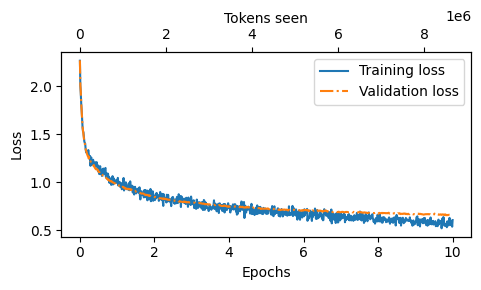

In [20]:
from previous_chapters_FT import plot_losses
# Alternatively:
# from llms_from_scratch.ch05 import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [21]:
from previous_chapters_FT import generate,token_ids_to_text,text_to_token_ids
torch.manual_seed(123)
for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

.في الأسفل تعليمة تصف المهمة المطلوبة.أكتب رد مناسب يجيب على المطلوب

### Instruction:
أكتب قصة قصيرة تكون مفهومة للأطفال في عمر 5-8. نهاية القصة يجب أن تكون سعيدة. عدد الشخصيات في القصة يجب أن يكون 2. بلد الأحداث هي  الجزائر. النشاط السباحة. يجب أن تحتوي القصة على شعور بالذنب. أضف تحولا غير متوقع في الأحداث: التبديل المفاجئ للأدوار بين الأبطال والأشرار. أكتب القصة مباشرة.

Correct response:
>> في قرية ساحلية صغيرة في الجزائر، كان يعيش صبي يدعى ياسين مع صديقه الأفضل، السلحفاة كريم. ياسين كان يحب السباحة أكثر من أي شيء في العالم، لكنه كان يخاف السباحة بعيدًا عن الشاطئ. كريم، بالمقابل، لم يخف أبدًا من أعماق البحر وكان دائمًا يشجع ياسين على محاولة السباحة بعيدًا قليلًا.

ذات يوم، اقترح كريم على ياسين مغامرة للسباحة إلى الصخرة الكبيرة التي كانت تبدو كجزيرة صغيرة في عرض البحر. ياسين شعر بالتردد، لكنه لم يرغب في إخبار كريم بخوفه. ومع ذلك، قرر أن يجرب. بينما كان يسبح، بدأ يشعر بالإرهاق والخوف من المياه العميقة. كريم لاحظ ذلك وعاد مسرعًا إلى صديقه ياسين ليساعده.

لكن فجأة، انقلبت الأدوار. كريم

In [22]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

100%|██████████| 99/99 [25:40<00:00, 15.56s/it]


In [23]:
print(test_data[0])

{'instruction': 'أكتب قصة قصيرة تكون مفهومة للأطفال في عمر 5-8. نهاية القصة يجب أن تكون سعيدة. عدد الشخصيات في القصة يجب أن يكون 2. بلد الأحداث هي  الجزائر. النشاط السباحة. يجب أن تحتوي القصة على شعور بالذنب. أضف تحولا غير متوقع في الأحداث: التبديل المفاجئ للأدوار بين الأبطال والأشرار. أكتب القصة مباشرة.', 'output': 'في قرية ساحلية صغيرة في الجزائر، كان يعيش صبي يدعى ياسين مع صديقه الأفضل، السلحفاة كريم. ياسين كان يحب السباحة أكثر من أي شيء في العالم، لكنه كان يخاف السباحة بعيدًا عن الشاطئ. كريم، بالمقابل، لم يخف أبدًا من أعماق البحر وكان دائمًا يشجع ياسين على محاولة السباحة بعيدًا قليلًا.\n\nذات يوم، اقترح كريم على ياسين مغامرة للسباحة إلى الصخرة الكبيرة التي كانت تبدو كجزيرة صغيرة في عرض البحر. ياسين شعر بالتردد، لكنه لم يرغب في إخبار كريم بخوفه. ومع ذلك، قرر أن يجرب. بينما كان يسبح، بدأ يشعر بالإرهاق والخوف من المياه العميقة. كريم لاحظ ذلك وعاد مسرعًا إلى صديقه ياسين ليساعده.\n\nلكن فجأة، انقلبت الأدوار. كريم، الذي كان دائمًا الشجاع، وجد نفسه محاصرًا في شباك صياد كانت مخبأة بين الأع

In [24]:
import re
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-small124M-sft.pth
